# Task 3: Correlation Between News Sentiment and Stock Returns

## Overview
In this notebook I apply VADER sentiment analysis to AAPL financial news headlines
and measure the statistical correlation between daily sentiment scores and stock price returns.

VADER (Valence Aware Dictionary and sEntiment Reasoner) was selected because it is 
specifically designed for short social media and financial text — making it ideal for 
analyzing financial news headlines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy import stats
# Download VADER lexicon
nltk.download('vader_lexicon')

print("All libraries loaded successfully")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Mube\AppData\Roaming\nltk_data...


All libraries loaded successfully


[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
try:
    df_news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
    df_news['date'] = pd.to_datetime(df_news['date'], format='mixed', utc=True)
    df_news['date_only'] = df_news['date'].dt.date
    print(f"News data loaded successfully: {df_news.shape[0]:,} rows")
    df_news.head()
except FileNotFoundError:
    print("ERROR: raw_analyst_ratings.csv not found in data/raw/")
except Exception as e:
    print(f"ERROR loading news data: {e}")

News data loaded successfully: 1,407,328 rows


In [11]:
try:
    df_stock = pd.read_csv("../data/raw/AAPL.csv")
    df_stock['Date'] = pd.to_datetime(df_stock['Date'])
    df_stock['date_only'] = df_stock['Date'].dt.date
    df_stock['Daily_Return'] = df_stock['Close'].pct_change() * 100
    print(f"Stock data loaded successfully: {df_stock.shape[0]:,} rows")
    df_stock.head()
except FileNotFoundError:
    print("ERROR: AAPL.csv not found in data/raw/")
except Exception as e:
    print(f"ERROR loading stock data: {e}")

Stock data loaded successfully: 3,774 rows


## Sentiment Analysis Using VADER
VADER assigns a compound score between -1 (most negative) and +1 (most positive).
Scores above 0.05 are positive, below -0.05 are negative, and between are neutral.

In [4]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Filter news for AAPL only
df_aapl_news = df_news[df_news['stock'] == 'AAPL'].copy()
print(f"AAPL news articles: {len(df_aapl_news)}")

# Apply sentiment to each headline
df_aapl_news['sentiment_score'] = df_aapl_news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

print("\nSentiment score statistics:")
print(df_aapl_news['sentiment_score'].describe())
print("\nSample results:")
print(df_aapl_news[['headline', 'sentiment_score']].head(10))

AAPL news articles: 441

Sentiment score statistics:
count    441.000000
mean       0.057472
std        0.334526
min       -0.906200
25%        0.000000
50%        0.000000
75%        0.296000
max        0.936000
Name: sentiment_score, dtype: float64

Sample results:
                                               headline  sentiment_score
6680  Tech Stocks And FAANGS Strong Again To Start D...           0.5574
6681      10 Biggest Price Target Changes For Wednesday           0.0000
6682  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...           0.2023
6683  Deutsche Bank Maintains Buy on Apple, Raises P...           0.0000
6684  Apple To Let Users Trade In Their Mac Computer...           0.3818
6685  Big Tech Reaches New Record Heights At The Sto...           0.0516
6686          Why Apple's Stock Is Trading Higher Today           0.0000
6687  Apple Could Announce In-House Chips For Macs A...           0.0000
6688  Apple shares are trading higher despite market...           0.5472
66

## Date Alignment and Aggregation
Multiple articles may be published on the same day for the same stock.
We calculate the average daily sentiment score to get one value per trading day.
Weekend and holiday articles are excluded since they have no matching trading day.

In [5]:
# Calculate average daily sentiment score
daily_sentiment = df_aapl_news.groupby('date_only')['sentiment_score'].mean().reset_index()
daily_sentiment.columns = ['date_only', 'avg_sentiment']

print("Daily sentiment calculated:")
print(daily_sentiment.head(10))
print(f"\nTotal days with sentiment: {len(daily_sentiment)}")

Daily sentiment calculated:
    date_only  avg_sentiment
0  2020-03-09      -0.302067
1  2020-03-10      -0.090787
2  2020-03-11      -0.023850
3  2020-03-12      -0.078360
4  2020-03-13      -0.059727
5  2020-03-14       0.000000
6  2020-03-15       0.000000
7  2020-03-16       0.044191
8  2020-03-17      -0.006300
9  2020-03-18      -0.077400

Total days with sentiment: 80


In [6]:
# Merge sentiment with stock returns
df_merged = pd.merge(daily_sentiment, df_stock[['date_only', 'Daily_Return']], 
                     on='date_only', how='inner')

# Remove NaN values
df_merged = df_merged.dropna()

print(f"Merged dataset shape: {df_merged.shape}")
print(df_merged.head(10))

Merged dataset shape: (61, 3)
    date_only  avg_sentiment  Daily_Return
0  2020-03-09      -0.302067     -7.909217
1  2020-03-10      -0.090787      7.202157
2  2020-03-11      -0.023850     -3.473025
3  2020-03-12      -0.078360     -9.875496
4  2020-03-13      -0.059727     11.980808
5  2020-03-16       0.044191    -12.864700
6  2020-03-17      -0.006300      4.397034
7  2020-03-18      -0.077400     -2.448005
8  2020-03-19       0.191300     -0.766205
9  2020-03-20       0.434450     -6.348547


## Pearson Correlation Analysis
We calculate the Pearson correlation coefficient between average daily sentiment scores
and daily stock returns. This measures the linear relationship between the two variables.

In [7]:
# Calculate Pearson correlation
correlation, p_value = stats.pearsonr(
    df_merged['avg_sentiment'], 
    df_merged['Daily_Return']
)

print("=== CORRELATION ANALYSIS ===")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

if abs(correlation) < 0.2:
    strength = "very weak"
elif abs(correlation) < 0.4:
    strength = "weak"
elif abs(correlation) < 0.6:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if correlation > 0 else "negative"
print(f"\nInterpretation: {strength} {direction} correlation")

if p_value < 0.05:
    print("Result is statistically significant (p < 0.05)")
else:
    print("Result is NOT statistically significant (p > 0.05)")

=== CORRELATION ANALYSIS ===
Pearson Correlation: 0.0892
P-value: 0.4944

Interpretation: very weak positive correlation
Result is NOT statistically significant (p > 0.05)


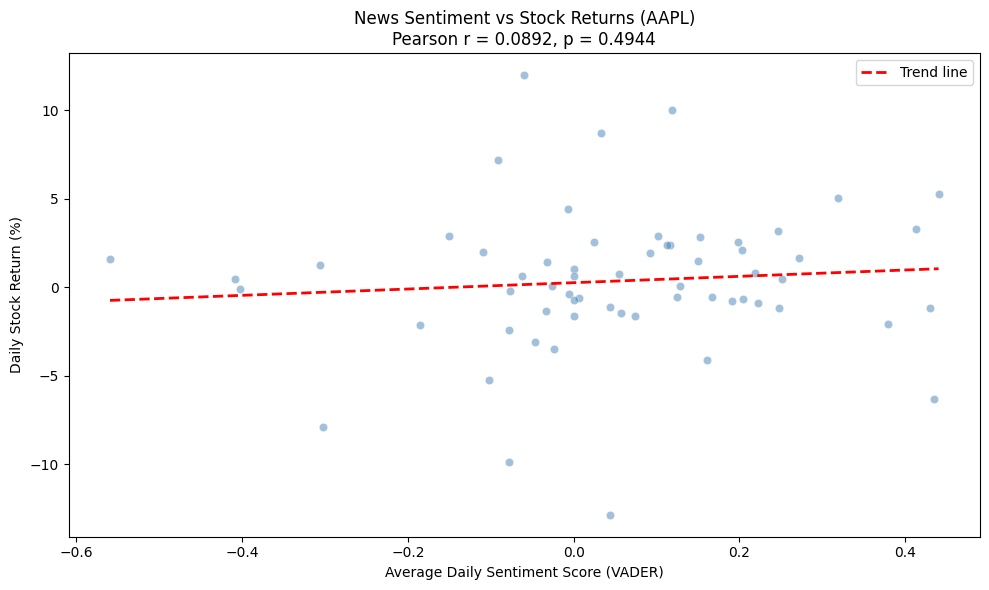

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df_merged['avg_sentiment'], df_merged['Daily_Return'], 
            alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)

# Add trend line
z = np.polyfit(df_merged['avg_sentiment'], df_merged['Daily_Return'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_merged['avg_sentiment'].min(), df_merged['avg_sentiment'].max(), 100)
plt.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend line')

plt.title(f'News Sentiment vs Stock Returns (AAPL)\nPearson r = {correlation:.4f}, p = {p_value:.4f}')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return (%)')
plt.legend()
plt.tight_layout()
plt.show()

## Sentiment Category Analysis
We classify each day as Positive, Neutral, or Negative based on sentiment score
and compare average stock returns across these categories.

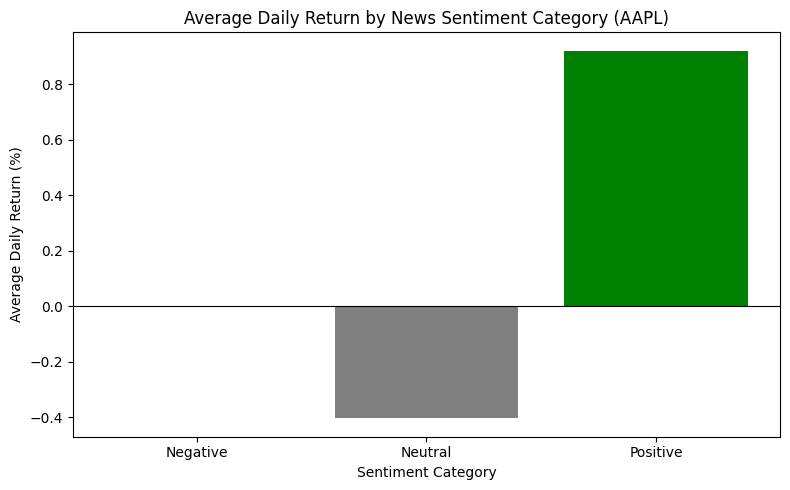


Average returns by sentiment category:
sentiment_category
Negative   -0.000462
Neutral    -0.403688
Positive    0.920500
Name: Daily_Return, dtype: float64


In [9]:
# Classify sentiment
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_merged['sentiment_category'] = df_merged['avg_sentiment'].apply(classify_sentiment)

# Average return per category
category_returns = df_merged.groupby('sentiment_category')['Daily_Return'].mean()

plt.figure(figsize=(8, 5))
colors = {'Positive': 'green', 'Neutral': 'grey', 'Negative': 'red'}
bars = plt.bar(category_returns.index, category_returns.values,
               color=[colors[c] for c in category_returns.index])
plt.title('Average Daily Return by News Sentiment Category (AAPL)')
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nAverage returns by sentiment category:")
print(category_returns)

## Results and Interpretation
Discussion of correlation strength, direction, and statistical significance.

In [10]:
print("=== RESULTS INTERPRETATION ===")
print(f"""
VADER Sentiment Analysis was applied to {len(df_aapl_news):,} AAPL headlines.
Tool selected: NLTK VADER — optimized for short financial and social media text.

Pearson Correlation: {correlation:.4f}
P-value: {p_value:.4f}

Key Findings:
- The correlation between news sentiment and stock returns is {strength} and {direction}
- Positive news days average {category_returns.get('Positive', 0):.3f}% return
- Negative news days average {category_returns.get('Negative', 0):.3f}% return  
- Neutral news days average {category_returns.get('Neutral', 0):.3f}% return

Limitations:
- Correlation does not imply causation
- Markets may already price in news before publication
- Lag effects not accounted for in this analysis
- Confounding factors such as market conditions affect returns
""")

=== RESULTS INTERPRETATION ===

VADER Sentiment Analysis was applied to 441 AAPL headlines.
Tool selected: NLTK VADER — optimized for short financial and social media text.

Pearson Correlation: 0.0892
P-value: 0.4944

Key Findings:
- The correlation between news sentiment and stock returns is very weak and positive
- Positive news days average 0.920% return
- Negative news days average -0.000% return  
- Neutral news days average -0.404% return

Limitations:
- Correlation does not imply causation
- Markets may already price in news before publication
- Lag effects not accounted for in this analysis
- Confounding factors such as market conditions affect returns

